# Lab 2 · Predict, measure, and explain Qwen3 inference

Read [background.md](../background.md) first. This notebook contains the former calculator, GEMM experiment, tutorial, and assessment in one sequence:

1. Configure a GPU roofline and explore its compute/bandwidth limits.
2. Derive decoder FLOPs and estimate Qwen3-8B/32B prefill and decode.
3. Calibrate copy bandwidth and GEMM throughput; freeze held-out predictions.
4. Load real checkpoints, check cached logits, and measure prefill and token intervals.
5. Calculate inference MFU, place measurements on the roofline, and explain residuals.

Start Jupyter from the course checkout: `jupyter lab chapters/02_performance_model/code/lab.ipynb` after the [shared setup](../../../shared/SETUP.md). The formulas and plots run without a GPU. Set `RUN_GPU = True` for calibration and `RUN_MODELS = True` for real checkpoint timing. Those paths require CUDA; there is no CPU timing substitute. Prerequisite: Chapter 1’s RMSNorm, RoPE, GQA, SwiGLU, checkpoint mapping, and cached forward implementation. [model.py](model.py) exports its tagged definitions from [Lab 1](../../01_reconstruct_qwen3/code/lab.ipynb), without running lab actions or requiring a live earlier kernel. This chapter adds reusable FLOP/traffic estimators and model benchmark functions around that same implementation.

The default compute ceiling is an **assumption for exploration**, not a published GB10 BF16 specification. Replace it with a documented dense peak for your GPU to report hardware MFU; otherwise every ratio remains explicitly conditional on the assumption. A measured GEMM ceiling is reported separately.

In [1]:
from dataclasses import asdict, dataclass
from pathlib import Path
import csv
import gc
import hashlib
import json
import math
import platform
import statistics
import subprocess
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').is_file())
NOTEBOOK = ROOT / 'chapters/02_performance_model/code/lab.ipynb'

def table(rows):
    if not rows:
        return
    names = list(rows[0])
    display(Markdown('| ' + ' | '.join(names) + ' |\n| ' + ' | '.join(['---'] * len(names)) + ' |\n' +
                     '\n'.join('| ' + ' | '.join(str(row[k]) for k in names) + ' |' for row in rows)))

In [2]:
RUN_GPU = False
RUN_MODELS = False
DEVICE = 'cuda:0'
DTYPE_NAME = 'bfloat16'                 # Benchmark supports bfloat16 or float16.
REPEATS = 3
WARMUP_RUNS = 2
DECODE_STEPS = 8                       # Eight decode calls => nine generated tokens including prefill's token.
MODEL_KEYS = ['8b', '32b']             # Loaded and released sequentially.
CASES = [(1, 128), (1, 512), (2, 128)] # (batch, prompt length): six conditions across both models.
ATTENTION_BACKEND = 'eager'            # Chapter 1 dense reference; no SDPA dispatch.
# Local Chapter 1 snapshots are used automatically when present; otherwise pinned Hub weights download.
LOCAL_MODEL_PATHS = {}
# This directory must be new: predictions and observations from earlier runs are preserved.
RUN_DIR = ROOT / 'results' / ('p02-' + time.strftime('%Y%m%d-%H%M%S'))

## 1. Build the hardware roofline

$P(I)=\min(C,\beta I)$, $I=F/Q$, and the ridge is $I_*=C/\beta$.
The horizontal axis is FLOP/byte and the vertical axis is TFLOP/s. Inputs use decimal TFLOP/s and GB/s. Keep **precision, density, and provenance** beside every compute number. Editing bandwidth changes the slope; editing compute changes the horizontal ceiling.

DGX Spark advertises [273 GB/s memory bandwidth and FP4 AI throughput](https://www.nvidia.com/en-us/products/workstations/dgx-spark/). Its FP4 number is not a BF16 denominator. The 125 TFLOP/s entry below is an explicit teaching assumption, not a conversion of that claim. You can add other precision ceilings, but do not use a precision unless the benchmark actually runs it.

In [3]:
@dataclass(frozen=True)
class Hardware:
    name: str
    bandwidth_gbps: float
    dense_peak_tflops: dict
    compute_basis: str                  # 'assumed' or 'documented'
    compute_source: str
    bandwidth_source: str

    def peak(self, precision):
        value = self.dense_peak_tflops[precision]
        if not math.isfinite(value) or value <= 0:
            raise ValueError('Provide a finite, positive dense peak for this precision.')
        if not math.isfinite(self.bandwidth_gbps) or self.bandwidth_gbps <= 0:
            raise ValueError('Bandwidth must be finite and positive.')
        if self.compute_basis not in {'assumed', 'documented'}:
            raise ValueError('Compute basis must be assumed or documented.')
        return value

    def ceiling(self, intensity, precision):
        return np.minimum(self.peak(precision), np.asarray(intensity) * self.bandwidth_gbps / 1000)


def roofline_ms(flops, byte_count, tflops, gbps, launch_us=0):
    if not all(math.isfinite(x) for x in (flops, byte_count, tflops, gbps, launch_us)):
        raise ValueError('Finite inputs required.')
    if min(flops, byte_count, launch_us) < 0 or min(tflops, gbps) <= 0:
        raise ValueError('Nonnegative work and positive rates required.')
    return 1000 * max(flops / (tflops * 1e12), byte_count / (gbps * 1e9)) + launch_us / 1000


def gemm(m, k, n, element_bytes=2):
    if min(m, k, n, element_bytes) <= 0:
        raise ValueError('Positive GEMM dimensions and element size required.')
    return 2 * m * k * n, element_bytes * (m*k + k*n + m*n)

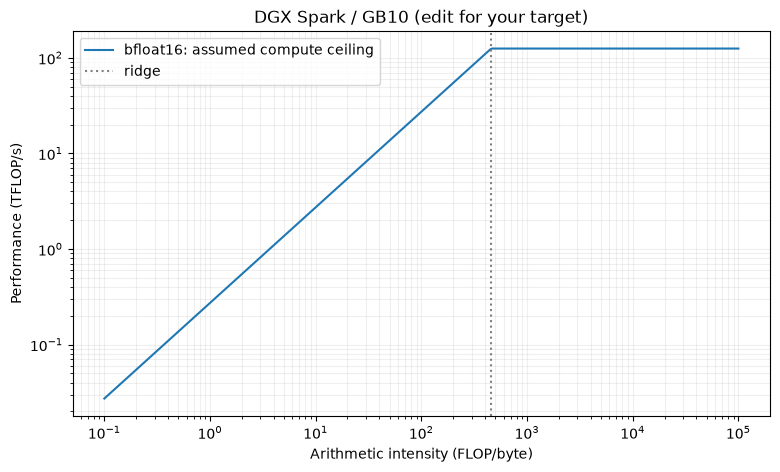

Ridge: 457.9 FLOP/byte


In [4]:
hardware = Hardware(
    name='DGX Spark / GB10 (edit for your target)',
    bandwidth_gbps=273,
    dense_peak_tflops={'bfloat16': 125.0, 'float16': 125.0},
    compute_basis='assumed',
    compute_source='Teaching assumption; replace with documented dense throughput for the selected dtype.',
    bandwidth_source='https://www.nvidia.com/en-us/products/workstations/dgx-spark/',
)
peak = hardware.peak(DTYPE_NAME)
mfu_label = 'MFU' if hardware.compute_basis == 'documented' else 'MFU (assumed peak)'
intensities = np.logspace(-1, 5, 400)
fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(intensities, hardware.ceiling(intensities, DTYPE_NAME), label=f'{DTYPE_NAME}: {hardware.compute_basis} compute ceiling')
ax.axvline(peak * 1000 / hardware.bandwidth_gbps, ls=':', color='gray', label='ridge')
ax.set(xlabel='Arithmetic intensity (FLOP/byte)', ylabel='Performance (TFLOP/s)', title=hardware.name)
ax.grid(True, which='both', alpha=.2)
ax.legend()
plt.show()
print(f'Ridge: {peak * 1000 / hardware.bandwidth_gbps:.1f} FLOP/byte')

**Try it:** double bandwidth, then compute. Predict the change for $I=1$ and $I=1000$ before rerunning. Why can a decode workload have low MFU while approaching its bandwidth limit?

## 2. Count decoder work from dimensions

Let $B$ be batch, $T$ new tokens per sequence, $P$ cached prefix tokens, $M=BT$, and $A=B(PT+T(T+1)/2)$ valid causal pairs. Prefill uses $(T,P)=(S,0)$; one decode call uses $(1,S)$ and attends **$S+1$** positions. The first generated token comes from prefill logits.

The function below exposes every matmul. GQA reduces K/V widths, but attention still uses all query heads. Qwen3-32B has $H_qR=8192\ne D=5120$. `attention_count='dense'` counts the full $BT(P+T)$ rectangle as a comparison; our default MFU uses useful causal matmul FLOPs. Norms, softmax, RoPE, activations, residuals and token selection execute, but are excluded from this dominant-matmul numerator. Their lower-order equations are in the background operator table.

The checkpoint revisions below pin the [8B config](https://huggingface.co/Qwen/Qwen3-8B/blob/b968826d9c46dd6066d109eabc6255188de91218/config.json) and [32B config](https://huggingface.co/Qwen/Qwen3-32B/blob/9216db5781bf21249d130ec9da846c4624c16137/config.json).

In [5]:
@dataclass(frozen=True)
class ModelDimensions:
    layers: int
    hidden: int
    intermediate: int
    query_heads: int
    kv_heads: int
    head_dim: int
    vocab: int

    @property
    def query_width(self):
        return self.query_heads * self.head_dim

    @property
    def kv_width(self):
        return self.kv_heads * self.head_dim

    @property
    def layer_matrix_parameters(self):
        d, q, k, i = self.hidden, self.query_width, self.kv_width, self.intermediate
        return 2*d*q + 2*d*k + 3*d*i

    @property
    def parameters(self):
        # Two residual-stream RMSNorms plus shared per-head Q/K norm weights per layer.
        return self.layers * (self.layer_matrix_parameters + 2*self.hidden + 2*self.head_dim) + 2*self.vocab*self.hidden + self.hidden

    @classmethod
    def from_config(cls, config):
        return cls(*(getattr(config, field) for field in (
            'num_hidden_layers', 'hidden_size', 'intermediate_size', 'num_attention_heads',
            'num_key_value_heads', 'head_dim', 'vocab_size')))


MODELS = {
    '8b': ModelDimensions(36, 4096, 12288, 32, 8, 128, 151936),
    '32b': ModelDimensions(64, 5120, 25600, 64, 8, 128, 151936),
}
REVISIONS = {'8b': 'b968826d9c46dd6066d109eabc6255188de91218',
             '32b': '9216db5781bf21249d130ec9da846c4624c16137'}
REPOS = {'8b': 'Qwen/Qwen3-8B', '32b': 'Qwen/Qwen3-32B'}


def decoder_layer_flops(c, batch, new_tokens, prefix_tokens=0, attention_count='causal'):
    if min(batch, new_tokens) <= 0 or prefix_tokens < 0:
        raise ValueError('Positive batch/new_tokens and nonnegative prefix required.')
    m = batch * new_tokens
    if attention_count == 'causal':
        pairs = batch * (prefix_tokens*new_tokens + new_tokens*(new_tokens+1)//2)
    elif attention_count == 'dense':
        pairs = batch * new_tokens * (prefix_tokens + new_tokens)
    else:
        raise ValueError('attention_count must be causal or dense')
    d, q, k, i = c.hidden, c.query_width, c.kv_width, c.intermediate
    return {'q_proj': 2*m*d*q, 'k_proj': 2*m*d*k, 'v_proj': 2*m*d*k,
            'qk': 2*pairs*q, 'av': 2*pairs*q, 'o_proj': 2*m*q*d,
            'gate_proj': 2*m*d*i, 'up_proj': 2*m*d*i, 'down_proj': 2*m*i*d}


def model_work(c, batch, new_tokens, prefix_tokens=0, logits_tokens=1, element_bytes=2,
               attention_count='causal'):
    if not 1 <= logits_tokens <= new_tokens or element_bytes <= 0:
        raise ValueError('Logits positions must be in [1, new_tokens]; element size must be positive.')
    ops = decoder_layer_flops(c, batch, new_tokens, prefix_tokens, attention_count)
    flops = c.layers * sum(ops.values()) + 2*batch*logits_tokens*c.hidden*c.vocab
    # Compulsory-data proxy, not a DRAM counter or a complete operator-traffic model.
    # Weights once per forward, selected embedding rows, old KV read and new KV written once.
    weight_bytes = element_bytes * (c.layers*(c.layer_matrix_parameters + 2*c.hidden + 2*c.head_dim)
                                   + c.hidden + c.hidden*c.vocab)
    embedding_bytes = element_bytes * batch * new_tokens * c.hidden
    kv_read_bytes = element_bytes * 2*c.layers*batch*prefix_tokens*c.kv_width
    kv_write_bytes = element_bytes * 2*c.layers*batch*new_tokens*c.kv_width
    io_bytes = element_bytes * (batch*new_tokens*c.hidden + batch*logits_tokens*c.vocab)
    byte_count = weight_bytes + embedding_bytes + kv_read_bytes + kv_write_bytes + io_bytes
    return dict(flops=flops, bytes_proxy=byte_count, intensity=flops/byte_count,
                weight_bytes=weight_bytes, kv_read_bytes=kv_read_bytes, kv_write_bytes=kv_write_bytes)


def metrics(work, seconds, hw, precision):
    if not math.isfinite(seconds) or seconds <= 0:
        raise ValueError('Positive finite measured seconds required.')
    achieved = work['flops'] / seconds / 1e12
    ceiling = float(hw.ceiling(work['intensity'], precision))
    return dict(achieved_tflops=achieved, mfu=achieved/hw.peak(precision),
                roofline_fraction_proxy=achieved/ceiling,
                bandwidth_proxy_gbps=work['bytes_proxy']/seconds/1e9)

In [6]:
table([dict(model=name, **asdict(c), parameters=f'{c.parameters:,}') for name, c in MODELS.items()])
ledger = []
for op in decoder_layer_flops(MODELS['8b'], 1, 1, 2048):
    ledger.append(dict(operator=op, **{name: f'{decoder_layer_flops(c, 1, 1, 2048)[op]:,}' for name, c in MODELS.items()}))
table(ledger)
print('Per-layer FLOPs: B=1, one decode token after a 2048-token prefix (2049 attended positions).')

estimates = []
for name, c in MODELS.items():
    for phase, t, p in [('prefill', 2048, 0), ('decode', 1, 2048)]:
        w = model_work(c, 1, t, p)
        estimates.append(dict(model=name, phase=phase, GFLOPs=round(w['flops']/1e9, 4),
            proxy_GB=round(w['bytes_proxy']/1e9, 4), intensity=round(w['intensity'], 2),
            ideal_bound_ms=round(roofline_ms(w['flops'], w['bytes_proxy'], peak, hardware.bandwidth_gbps), 3)))
table(estimates)

| model | layers | hidden | intermediate | query_heads | kv_heads | head_dim | vocab | parameters |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 8b | 36 | 4096 | 12288 | 32 | 8 | 128 | 151936 | 8,190,735,360 |
| 32b | 64 | 5120 | 25600 | 64 | 8 | 128 | 151936 | 32,762,123,264 |

| operator | 8b | 32b |
| --- | --- | --- |
| q_proj | 33,554,432 | 83,886,080 |
| k_proj | 8,388,608 | 10,485,760 |
| v_proj | 8,388,608 | 10,485,760 |
| qk | 16,785,408 | 33,570,816 |
| av | 16,785,408 | 33,570,816 |
| o_proj | 33,554,432 | 83,886,080 |
| gate_proj | 100,663,296 | 262,144,000 |
| up_proj | 100,663,296 | 262,144,000 |
| down_proj | 100,663,296 | 262,144,000 |

Per-layer FLOPs: B=1, one decode token after a 2048-token prefix (2049 attended positions).


| model | phase | GFLOPs | proxy_GB | intensity | ideal_bound_ms |
| --- | --- | --- | --- | --- | --- |
| 8b | prefill | 29688.6626 | 15.4727 | 1918.78 | 237.509 |
| 8b | decode | 16.3447 | 15.4393 | 1.06 | 56.554 |
| 32b | prefill | 132219.9765 | 64.5475 | 2048.41 | 1057.76 |
| 32b | decode | 68.2641 | 64.5059 | 1.06 | 236.285 |

**Check by hand:** derive the 32B Q projection using $[M,5120][5120,8192]$. Then change batch, prompt length and `logits_tokens`. Why does `logits_tokens=2048` change scoring cost but not decoder-layer cost? Why does replacing query heads with KV heads undercount attention?

`bytes_proxy` assumes resident weights stream once per call and counts only compulsory data and boundary I/O. It omits intermediate activation traffic, tiled KV rereads, dynamic-cache copying, allocator traffic, and materialized scores. New prefill K/V can feed attention on chip, so their cache writes are counted but an additional compulsory read is not assumed. Consequently $F/Q_{proxy}$ is an **optimistic intensity estimate**, not a measured hardware-counter coordinate. It can place a measured point beyond the proxy roofline; that is a model-assumption diagnostic, not proof of exceeding physical bandwidth.

## 3. Calibrate hardware and freeze six GEMM predictions

Use device-to-device copy buffers larger than last-level cache, counting both read and write. GEMM outputs are preallocated. Warmup and allocation are outside the CUDA-event region. Copy bandwidth and GEMM throughput are empirical ceilings for these shapes, not manufacturer peaks. Repeated small GEMMs may reuse cached weights.

The small-call floor is an observed workload interval including possible dispatch gaps, not a pure launch latency. Freeze calibration at $M=1,16,512$ and save six predictions before measuring $M=2,4,8,32,64,128$. A single effective rate is deliberately simple; its errors motivate shape-specific calibration.

In [7]:
def require_cuda(device, precision):
    import torch
    if not torch.cuda.is_available() or torch.device(device).type != 'cuda':
        raise RuntimeError('CUDA required; CPU timing fallback is disabled.')
    if precision not in {'bfloat16', 'float16'}:
        raise ValueError('This benchmark supports bfloat16 and float16 only.')
    torch.cuda.set_device(device)
    # Chapter 1 attention matmuls use FP32 even with BF16/FP16 weights.
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    if precision == 'bfloat16' and not torch.cuda.is_bf16_supported():
        raise RuntimeError('Selected GPU does not support BF16.')
    return torch


def cuda_samples(fn, repeats=3, inner=10, warmup=5, device='cuda:0'):
    import torch
    if min(repeats, inner) <= 0 or warmup < 0:
        raise ValueError('Positive repeat/inner counts and nonnegative warmup required.')
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    with torch.inference_mode(), torch.cuda.device(device):
        for _ in range(warmup):
            fn()
        torch.cuda.synchronize(device)
        samples = []
        for _ in range(repeats):
            start.record()
            for _ in range(inner):
                fn()
            end.record()
            end.synchronize()
            samples.append(start.elapsed_time(end)/inner)
    return samples


def write_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')


def write_csv(path, rows):
    if rows:
        with Path(path).open('w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0]))
            writer.writeheader()
            writer.writerows(rows)


def calibrate(device, precision, repeats, out_dir):
    torch = require_cuda(device, precision)
    dtype = getattr(torch, precision)
    # 256 MiB per buffer; increase if necessary to exceed your GPU's cache.
    source = torch.ones(64*1024*1024, device=device, dtype=torch.float32)
    dest = torch.empty_like(source)
    copy_bytes = 2 * source.numel() * source.element_size()
    copies = cuda_samples(lambda: dest.copy_(source), repeats, device=device)
    gbps = copy_bytes / (statistics.median(copies)*1e6)
    del source, dest
    small = torch.ones(1, 1, device=device, dtype=dtype)
    small_out = torch.empty_like(small)
    floor_ms = min(cuda_samples(lambda: torch.mm(small, small, out=small_out), repeats, inner=50, device=device))
    calibration, rates = [], []
    for m in [1, 16, 512]:
        x = torch.randn(m, 4096, device=device, dtype=dtype)
        w = torch.randn(4096, 4096, device=device, dtype=dtype)
        y = torch.empty(m, 4096, device=device, dtype=dtype)
        samples = cuda_samples(lambda: torch.mm(x, w, out=y), repeats, device=device)
        rates.append(gemm(m, 4096, 4096)[0] / (statistics.median(samples)*1e9))
        calibration.extend(dict(m=m, repeat=r, cuda_ms=s) for r, s in enumerate(samples))
    effective_tflops = max(rates)
    predicted = {m: roofline_ms(*gemm(m, 4096, 4096), effective_tflops, gbps, floor_ms*1000)
                 for m in [2, 4, 8, 32, 64, 128]}
    result = dict(effective_tflops=effective_tflops, copy_gbps=gbps, small_call_floor_ms=floor_ms,
                  predicted_gemm_ms=predicted, copy_buffer_bytes=copy_bytes//2)
    write_json(out_dir/'calibration_prediction.json', result)  # Before held-out timings.
    write_csv(out_dir/'calibration.csv', calibration)
    write_csv(out_dir/'bandwidth.csv', [dict(repeat=r, bytes=copy_bytes, cuda_ms=s) for r, s in enumerate(copies)])
    measured = []
    for m in predicted:
        x = torch.randn(m, 4096, device=device, dtype=dtype)
        w = torch.randn(4096, 4096, device=device, dtype=dtype)
        y = torch.empty(m, 4096, device=device, dtype=dtype)
        samples = cuda_samples(lambda: torch.mm(x, w, out=y), repeats, device=device)
        measured.extend(dict(m=m, repeat=r, predicted_ms=predicted[m], cuda_ms=s) for r, s in enumerate(samples))
    write_csv(out_dir/'gemm_results.csv', measured)
    return result, measured

In [8]:
calibration, gemm_rows = None, []
model_rows, model_status, loaded_metadata = [], [], []
if RUN_MODELS and not RUN_GPU:
    raise ValueError('Enable RUN_GPU before running model benchmarks.')
if RUN_GPU:
    torch = require_cuda(DEVICE, DTYPE_NAME)
    RUN_DIR.mkdir(parents=True, exist_ok=False)
    manifest = dict(hardware=asdict(hardware), precision=DTYPE_NAME, gpu=torch.cuda.get_device_name(DEVICE),
        cuda=torch.version.cuda, torch=torch.__version__, python=platform.python_version(),
        device=DEVICE, repeats=REPEATS, warmup_runs=WARMUP_RUNS, decode_steps=DECODE_STEPS,
        cases=CASES, attention_backend=ATTENTION_BACKEND, cache='per-layer (K,V) tensors; torch.cat append',
        attention_matmul_precision='float32', tf32=False,
        model_revisions=REVISIONS, compute_count='causal matmuls, final-position logits',
        bytes='compulsory-data proxy; not measured DRAM traffic',
        timing='CUDA forward intervals; synchronized wall time through greedy token ready',
        notebook_sha256=hashlib.sha256(NOTEBOOK.read_bytes()).hexdigest())
    write_json(RUN_DIR/'manifest.json', manifest)
    calibration, gemm_rows = calibrate(DEVICE, DTYPE_NAME, REPEATS, RUN_DIR)
    print(calibration)
else:
    print('Analytical mode: GPU calibration and model timing are unmeasured.')

Analytical mode: GPU calibration and model timing are unmeasured.


In [9]:
if gemm_rows:
    gemm_summary = []
    for m in sorted({r['m'] for r in gemm_rows}):
        group = [r for r in gemm_rows if r['m'] == m]
        measured = statistics.median(r['cuda_ms'] for r in group)
        predicted = group[0]['predicted_ms']
        gemm_summary.append(dict(m=m, measured_ms=measured, predicted_ms=predicted,
                                 relative_error=abs(predicted-measured)/measured))
    table(gemm_summary)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.loglog([r['m'] for r in gemm_summary], [r['predicted_ms'] for r in gemm_summary], 'o-', label='frozen prediction')
    ax.loglog([r['m'] for r in gemm_summary], [r['measured_ms'] for r in gemm_summary], 's-', label='measured median')
    ax.set(xlabel='GEMM M', ylabel='Latency (ms)', title='Held-out Q-projection shapes')
    ax.legend()
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'gemm_prediction.{extension}', bbox_inches='tight')
    plt.show()

## 4. Freeze full-model estimates, then load real Qwen3

The checkpoint paths from Chapter 1 are detected first. Otherwise the loader downloads the pinned repository through `snapshot_download`. For an explicit download, run `hf download Qwen/Qwen3-8B --revision b968826d9c46dd6066d109eabc6255188de91218` or the corresponding 32B repository/revision above. No credentials are needed for these public weights.

BF16 weight storage alone is approximately 16.38 GB (8B) and 65.52 GB (32B), plus cache, activations, load overhead, and runtime memory. Models are loaded one at a time on exactly one GPU without CPU offload. A capacity failure is saved as **unmeasured**; it never creates a timing point. On unified-memory systems, reclaimable host file cache can make free CUDA memory an overly pessimistic capacity check, so the GB10 preflight uses Linux `MemAvailable`, including reclaimable file cache. Other GPUs use free device memory. A working-memory reserve is added to weights and KV capacity; this estimate cannot guarantee a fit. The Chapter 1 reference exported by `model.py` is initialized on meta, audited, and filled one safetensors shard at a time using Chapter 1’s strict loader. Transformers is a correctness oracle in the regression tests; the timed model is the course implementation. Closing each shard releases its CPU backing storage before the next opens, bounding staging memory on shared host/device RAM.

`prediction.json` records the original hardware lower bounds and a simple calibrated aggregate estimate **before** real-model runs. The aggregate estimate omits sequential-kernel and host overhead; compare errors without promising it is an accurate latency predictor. To build a stronger model, replace it with a sum of operator bounds using shape-specific rates.

The benchmark uses equal-length synthetic token IDs to control $B,S$. It is a performance workload, not a quality evaluation. Tokenization, download, model load, and prompt construction occur outside timing. Every prefill starts with an empty cache. `decode=True` selects final-position logits and matches the FLOP estimator. A short cached-versus-full-prefix logits check runs before timing. The caller owns the per-layer `(K, V)` cache and retains each returned replacement.

The reference materializes dense attention scores, expands grouped KV heads, and copies the prefix on cache append. QK/AV and softmax execute in FP32 even with BF16/FP16 weights; norms and RoPE also use FP32 intermediates. The reported MFU remains useful causal matmul FLOPs divided by the selected weight-precision peak, a modeling convention rather than utilization of every executed instruction. Predict a larger gap from the ideal bound as score storage and cache-copy traffic grow; compare prompt lengths to test that prediction. These costs are omitted from the compulsory-byte proxy. Preserve `source_sha256` with results and restart the kernel after editing Chapter 1 definitions.

In [10]:
predictions = []
for key in MODEL_KEYS:
    c = MODELS[key]
    for batch, prompt in CASES:
        for phase in ['prefill', 'decode']:
            steps = [0] if phase == 'prefill' else range(DECODE_STEPS)
            for step in steps:
                t, p = (prompt, 0) if phase == 'prefill' else (1, prompt + step)
                work = model_work(c, batch, t, p)
                predicted_ms = roofline_ms(work['flops'], work['bytes_proxy'], peak, hardware.bandwidth_gbps)
                calibrated_ms = (roofline_ms(work['flops'], work['bytes_proxy'], calibration['effective_tflops'], calibration['copy_gbps'])
                                 if calibration else None)
                predictions.append(dict(model=key, batch=batch, prompt=prompt, phase=phase, step=step,
                    prefix_tokens=p, new_tokens=t, **work, ideal_bound_ms=predicted_ms,
                    calibrated_aggregate_ms=calibrated_ms))
if RUN_GPU:
    write_json(RUN_DIR/'prediction.json', predictions)
print(f'{len(predictions)} phase/step estimates frozen; real-model timing has not started.')

54 phase/step estimates frozen; real-model timing has not started.


In [11]:
def resolve_checkpoint(key):
    if key in LOCAL_MODEL_PATHS:
        path = Path(LOCAL_MODEL_PATHS[key]).expanduser().resolve()
        if not (path/'config.json').is_file():
            raise FileNotFoundError(path/'config.json')
        return str(path), {}
    local = ROOT / 'models' / f'qwen3-{key}' / REVISIONS[key]
    if (local/'config.json').is_file():
        return str(local), {}
    return REPOS[key], {'revision': REVISIONS[key]}


def reference_model_module():
    # Import by package path so this works from the course root or notebook folder.
    import importlib
    import sys
    if str(ROOT) not in sys.path:
        sys.path.insert(0, str(ROOT))
    return importlib.import_module('chapters.02_performance_model.code.model')


def load_resident_model(snapshot, device, precision, backend):
    """Load the Chapter 1 implementation through its strict checkpoint audit."""
    import torch
    if backend != 'eager':
        raise ValueError('The Chapter 1 reference supports only eager attention.')
    reference = reference_model_module()
    model, _ = reference.load_checkpoint(snapshot, device, getattr(torch, precision))
    return model


def check_capacity(c, device, cases, decode_steps):
    import torch
    free, total = torch.cuda.mem_get_info(device)
    # GB10 shares host/device RAM; MemAvailable includes reclaimable file cache.
    available = free
    if 'GB10' in torch.cuda.get_device_name(device) and Path('/proc/meminfo').is_file():
        info = dict(line.split(':', 1) for line in Path('/proc/meminfo').read_text().splitlines())
        available = min(total, int(info['MemAvailable'].split()[0])*1024)
    weights = 2*c.parameters
    max_kv = max(4*c.layers*b*(s+decode_steps)*c.kv_width for b, s in cases)
    # Conservative working allowance, not an exact activation-capacity model.
    reserve = max(8*1024**3, weights*.15) + max_kv
    if weights + reserve > available:
        raise torch.cuda.OutOfMemoryError(
            f'Capacity preflight: need about {(weights+reserve)/1e9:.1f} GB including reserve; '
            f'{available/1e9:.1f} GB available. Reduce work or use a larger GPU.')
    return dict(available_bytes=available, weight_bytes=weights, reserve_bytes=reserve)


def load_qwen(key, device, precision, backend, cases, decode_steps):
    torch = require_cuda(device, precision)
    from transformers import AutoConfig
    from huggingface_hub import snapshot_download
    capacity = check_capacity(MODELS[key], device, cases, decode_steps)
    source, kwargs = resolve_checkpoint(key)
    config = AutoConfig.from_pretrained(source, **kwargs)
    if ModelDimensions.from_config(config) != MODELS[key] or config.tie_word_embeddings:
        raise ValueError('Checkpoint dimensions/tied weights differ from the analytical model.')
    if getattr(config, 'quantization_config', None) or getattr(config, 'use_sliding_window', False):
        raise ValueError('This lab expects dense, unquantized, full-attention Qwen3.')
    print(f'Loading {key} from {source}; CUDA free/total GB:', [round(x/1e9, 2) for x in torch.cuda.mem_get_info(device)], flush=True)
    if kwargs:
        source = snapshot_download(repo_id=source, revision=kwargs['revision'],
                                   allow_patterns=['*.json', '*.safetensors'])
    model = load_resident_model(source, device, precision, backend)
    if any(p.device != torch.device(device) or p.dtype != getattr(torch, precision) for p in model.parameters()):
        raise RuntimeError('All parameters must reside on the target GPU in the selected precision.')
    if sum(p.numel() for p in model.parameters()) != MODELS[key].parameters:
        raise ValueError('Actual parameter count differs from the model ledger.')
    metadata = dict(model=key, source=source, capacity_preflight=capacity, requested_revision=kwargs.get('revision'),
                    resolved_revision=getattr(config, '_commit_hash', None),
                    config_sha256=hashlib.sha256((Path(source)/'config.json').read_bytes()).hexdigest(),
                    implementation='Chapter 1 TinyQwen3', attention_backend='eager',
                    source_sha256=reference_model_module().source_hashes())
    return model, metadata


def check_cached_logits(model, device):
    import torch
    with torch.inference_mode():
        ids = torch.tensor([[11, 25, 76, 93]], device=device)
        oracle, _ = model(ids, decode=True)
        _, prefix = model(ids[:, :-1], decode=True)
        cached, _ = model(ids[:, -1:], prefix, decode=True)
        # Freeze this BF16 tolerance before accepting benchmark data; do not loosen on failure.
        torch.testing.assert_close(cached.float(), oracle.float(), atol=0.25, rtol=0.02)
        return float((cached.float()-oracle.float()).abs().max().item())


def benchmark_model(model, key, cases, repeats, warmup_runs, decode_steps, device, precision):
    torch = require_cuda(device, precision)
    if min(repeats, decode_steps) <= 0 or warmup_runs < 1:
        raise ValueError('Positive repeats/decode steps and at least one full warmup run required.')
    rows = []
    c = MODELS[key]
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    for batch, prompt in cases:
        if min(batch, prompt) <= 0 or prompt + decode_steps > model.max_position_embeddings:
            raise ValueError('Workload outside configured context range.')
        generator = torch.Generator(device=device).manual_seed(42)
        ids = torch.randint(100, 10000, (batch, prompt), device=device, generator=generator)
        with torch.inference_mode():
            for repeat in range(-warmup_runs, repeats):
                cache = None
                next_ids = ids
                for step in range(-1, decode_steps):
                    phase = 'prefill' if step == -1 else 'decode'
                    prefix = 0 if step == -1 else prompt + step
                    expected_cache = prefix + next_ids.shape[1]
                    # Synchronized wall interval runs through greedy token availability.
                    # Events bracket forward only, not token selection or the final host wait.
                    torch.cuda.synchronize(device)
                    begin = time.perf_counter()
                    start.record()
                    logits, updated_cache = model(next_ids, cache, decode=True)
                    end.record()
                    next_ids = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                    torch.cuda.synchronize(device)
                    wall_ms = (time.perf_counter() - begin)*1000
                    cuda_ms = start.elapsed_time(end)
                    cache = updated_cache
                    if any(k.shape[2] != expected_cache or v.shape[2] != expected_cache for k, v in cache):
                        raise AssertionError('Cache length does not match the modeled prefix.')
                    if repeat >= 0:
                        work = model_work(c, batch, prompt if step == -1 else 1, prefix)
                        rows.append(dict(model=key, batch=batch, prompt=prompt, phase=phase,
                            repeat=repeat, step=max(step, 0), prefix_tokens=prefix,
                            attended_positions=expected_cache, cuda_ms=cuda_ms, token_ready_ms=wall_ms,
                            **work, **metrics(work, cuda_ms/1000, hardware, precision)))
                    del logits, updated_cache
                del cache, next_ids
    return rows

In [12]:
if RUN_MODELS:
    import transformers
    manifest['transformers'] = transformers.__version__
    for key in MODEL_KEYS:
        model = None
        try:
            model, metadata = load_qwen(key, DEVICE, DTYPE_NAME, ATTENTION_BACKEND, CASES, DECODE_STEPS)
            metadata['cached_logits_max_abs_error'] = check_cached_logits(model, DEVICE)
            loaded_metadata.append(metadata)
            model_rows.extend(benchmark_model(model, key, CASES, REPEATS, WARMUP_RUNS, DECODE_STEPS, DEVICE, DTYPE_NAME))
            model_status.append(dict(model=key, status='measured'))
        except torch.cuda.OutOfMemoryError as error:
            model_status.append(dict(model=key, status='unmeasured: insufficient GPU memory', detail=str(error)))
        finally:
            del model
            gc.collect()
            torch.cuda.empty_cache()
            write_csv(RUN_DIR/'results.csv', model_rows)
            write_json(RUN_DIR/'model_status.json', model_status)
            manifest['loaded_models'] = loaded_metadata
            write_json(RUN_DIR/'manifest.json', manifest)
    table(model_status)
else:
    print('Real checkpoints unmeasured. Set RUN_GPU and RUN_MODELS to True, then run from the configuration cell.')

Real checkpoints unmeasured. Set RUN_GPU and RUN_MODELS to True, then run from the configuration cell.


## 5. MFU, TTFT, TBT, and the model roofline

For each call, inference MFU is $F_{model}/(t_{forward}C_{peak})$. This is the **causal matmul inference convention**: no backward pass and no $6P$ training multiplier. A measured GEMM rate must not replace the peak denominator silently. Here it produces a separate `fraction_of_calibrated_compute` metric.

`cuda_ms` measures the forward interval (including device idle gaps within it); `token_ready_ms` measures synchronized wall time through greedy selection. Prefill's wall interval is **local TTFT** from ready device inputs. Decode wall intervals are **local TBT** with synchronization after each token. They exclude request queues, tokenization, network delivery and serving scheduling; they are not server TTFT/TBT or maximum-throughput generation. We generate one first token plus `DECODE_STEPS` subsequent tokens and deliberately continue through EOS to keep work fixed.

Decode costs grow as the cache grows. Raw rows retain every prefix length. Aggregate achieved FLOP/s uses **sum(F)/sum(time)**, never the mean of step MFUs. Each plotted point is the median of independent repeat aggregates, with min/max bars. The point's x-coordinate uses sum(F)/sum(proxy bytes), explicitly labeled as modeled traffic.

In [13]:
def summarize_model_rows(rows, hw, precision, calibration=None):
    summary = []
    groups = sorted({(r['model'], r['batch'], r['prompt'], r['phase']) for r in rows})
    for key, batch, prompt, phase in groups:
        group = [r for r in rows if (r['model'], r['batch'], r['prompt'], r['phase']) == (key, batch, prompt, phase)]
        aggregates = []
        for repeat in sorted({r['repeat'] for r in group}):
            run = [r for r in group if r['repeat'] == repeat]
            f, q = sum(r['flops'] for r in run), sum(r['bytes_proxy'] for r in run)
            seconds = sum(r['cuda_ms'] for r in run)/1000
            aggregates.append(metrics(dict(flops=f, bytes_proxy=q, intensity=f/q), seconds, hw, precision))
        achieved = [r['achieved_tflops'] for r in aggregates]
        median_rate = statistics.median(achieved)
        mean_call_ms = [statistics.mean(r['token_ready_ms'] for r in group if r['repeat'] == repeat)
                        for repeat in sorted({r['repeat'] for r in group})]
        forward_ms = [statistics.mean(r['cuda_ms'] for r in group if r['repeat'] == repeat)
                      for repeat in sorted({r['repeat'] for r in group})]
        summary.append(dict(model=key, batch=batch, prompt=prompt, phase=phase,
            local_metric='TTFT' if phase == 'prefill' else 'mean TBT',
            token_ready_ms=statistics.median(mean_call_ms), token_ready_min_ms=min(mean_call_ms),
            token_ready_max_ms=max(mean_call_ms),
            forward_ms=statistics.median(forward_ms),
            intensity=sum(r['flops'] for r in group)/sum(r['bytes_proxy'] for r in group),
            achieved_tflops=median_rate, min_tflops=min(achieved), max_tflops=max(achieved),
            mfu=median_rate/hw.peak(precision), mfu_basis=hw.compute_basis,
            fraction_of_calibrated_compute=median_rate/calibration['effective_tflops'] if calibration else None,
            decode_tokens_per_second=batch*1000/statistics.median(mean_call_ms) if phase == 'decode' else None))
    return summary

In [14]:
summary = summarize_model_rows(model_rows, hardware, DTYPE_NAME, calibration)
if summary:
    table([{k: (round(v, 4) if isinstance(v, float) else v) for k, v in r.items()} for r in summary])
    print(f'MFU column means {mfu_label}; FLOPs are causal matmul work.')
    for row in summary:
        predicted = [r for r in predictions if (r['model'], r['batch'], r['prompt'], r['phase']) ==
                     (row['model'], row['batch'], row['prompt'], row['phase'])]
        row['ideal_bound_ms'] = statistics.mean(r['ideal_bound_ms'] for r in predicted)
        row['calibrated_aggregate_ms'] = statistics.mean(r['calibrated_aggregate_ms'] for r in predicted)
        row['relative_error'] = abs(row['calibrated_aggregate_ms']-row['forward_ms'])/row['forward_ms']
    write_csv(RUN_DIR/'summary.csv', summary)
    write_json(RUN_DIR/'summary.json', dict(points=summary,
        median_relative_error=statistics.median(r['relative_error'] for r in summary),
        mfu_label=mfu_label, model_status=model_status))
else:
    print('No measured model points: the next chart contains only the configured hardware roofline.')

No measured model points: the next chart contains only the configured hardware roofline.


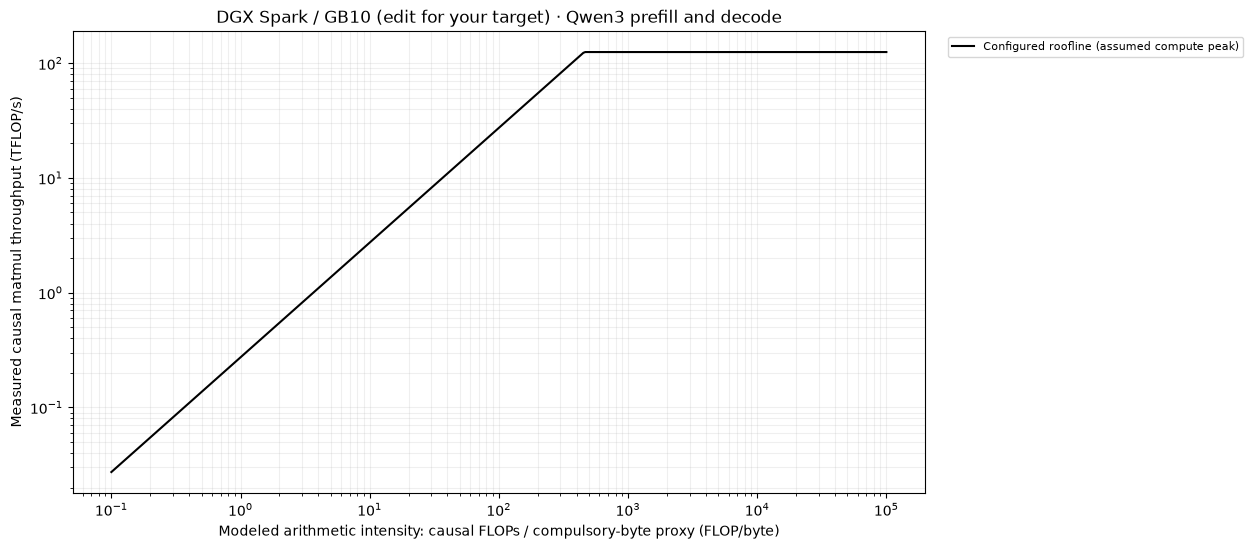

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.loglog(intensities, hardware.ceiling(intensities, DTYPE_NAME), color='black',
          label=f'Configured roofline ({hardware.compute_basis} compute peak)')
if calibration:
    ax.loglog(intensities, np.minimum(calibration['effective_tflops'], intensities*calibration['copy_gbps']/1000),
              '--', color='gray', label='Measured GEMM/copy calibration envelope')
for r in summary:
    y = r['achieved_tflops']
    ax.errorbar(r['intensity'], y, yerr=[[y-r['min_tflops']], [r['max_tflops']-y]],
        fmt='o' if r['phase'] == 'prefill' else 's', capsize=3,
        label=f"{r['model']} {r['phase']} B={r['batch']} S={r['prompt']} | {mfu_label}={r['mfu']:.1%}")
ax.set(xlabel='Modeled arithmetic intensity: causal FLOPs / compulsory-byte proxy (FLOP/byte)',
       ylabel='Measured causal matmul throughput (TFLOP/s)', title=hardware.name + ' · Qwen3 prefill and decode')
ax.grid(True, which='both', alpha=.2)
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
if RUN_GPU:
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'roofline.{extension}', bbox_inches='tight')
plt.show()

if summary:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for phase, ax in zip(['prefill', 'decode'], axes):
        selected = [r for r in summary if r['phase'] == phase]
        x = np.arange(len(selected))
        y = np.array([r['token_ready_ms'] for r in selected])
        ax.bar(x, y, yerr=[y-np.array([r['token_ready_min_ms'] for r in selected]),
                          np.array([r['token_ready_max_ms'] for r in selected])-y], capsize=3)
        ax.set_xticks(x, [f"{r['model']}\nB{r['batch']} S{r['prompt']}" for r in selected])
        ax.set(ylabel='Synchronized local latency (ms)', title='Local TTFT' if phase == 'prefill' else 'Local mean TBT')
    fig.tight_layout()
    for extension in ['svg', 'png']:
        fig.savefig(RUN_DIR/f'latency.{extension}', bbox_inches='tight')
    plt.show()
    print('Artifacts:', RUN_DIR)

## 6. Explain the measurements and test a prediction

Before changing code, write your answers here:

- Reproduce one operator FLOP count, one MFU value, and one plotted intensity from the raw CSV. State the byte and causal-pair assumptions.
- Compare prefill and decode at fixed batch. Compare $B=1$ and $B=2$ at fixed context. Does higher MFU imply lower user TBT? Distinguish aggregate throughput from per-request latency.
- Plot measured forward time against the frozen estimate. Compute $|t_{pred}-t_{measured}|/t_{measured}$ and inspect signed residuals. The 25% median-error target is diagnostic; this compulsory-byte aggregate model may miss it substantially.
- Identify a residual that grows with context, one that grows with batch, or a nearly constant gap. Propose a measurement that separates cache copying, attention rereads, GEMM efficiency, and host dispatch.
- Capture a separate Nsight Systems trace with prefill/decode ranges, then profile a few dominant kernels using Nsight Compute. Profiling/replay times must not replace the ordinary timing rows. Hardware-counter bytes can replace the byte proxy only when measurement scope matches the FLOP/time scope.
- Predict one intervention (larger batch, optimized attention, static cache, or fewer logits positions). Freeze new predictions in a new run directory and test new conditions. Keep the original held-out score.

An aggregate roofline is a ceiling, not a schedule. For serial kernels use $\sum_j\max(F_j/C_j,Q_j/\beta_j)$ plus critical-path overhead. Add shape-specific GEMM calibration and attention measurements before expecting reliable latency predictions.

### Completion evidence

| Milestone | Evidence |
|---|---|
| Theory | Hand derivation of roofline ridge, GQA Q/O shapes, causal prefill and cached decode FLOPs |
| Calibration | Hardware identity/dtype/provenance, raw copy/GEMM repeats, six predictions saved before observations |
| Real models | Cached-logit check; at least three repeats; both 8B and 32B measured in both phases, or explicit capacity-limited unmeasured status |
| Analysis | Raw step contexts/timings, local TTFT/TBT, qualified MFU, labeled roofline and latency plots, prediction residuals |
| Full project | At least six feasible workload conditions spanning both models/phases; trace-supported diagnosis and one tested intervention |

Submit the result directory and a 400–600 word entry note with your original prediction, one reconstructed calculation, and a figure interpretation. For the full project, extend it to a 1,200–2,000 word memo using the [common rubric](../../../shared/REPORT.md). An explained negative result is valid. No synthetic or unperformed run counts as real Qwen timing.

If CUDA is unavailable, complete Sections 1–2 and predictions only. If 32B does not fit, reduce batch/context or use a larger single GPU and retain its separate hardware config. CPU offload, quantization, or tensor parallelism require a different performance model. If cached logits fail the frozen tolerance, resolve the discrepancy before benchmarking. If a result directory exists, choose a new one. With few repeats, min/max bars show observed variation, not confidence intervals.

### Handoff to Chapter 3: select an optimization opportunity

Carry forward one workload’s manifest, frozen theoretical bound and calibrated estimate, raw observed latencies, and a separate profile. Record the signed residual, the suspected mechanism, and evidence that would distinguish it from another cause. Estimate the target operation’s fraction of model time and predict the whole-model benefit of one kernel change, including adapter overhead, using [Chapter 3’s gap analysis](../../03_kernels/background.md#from-chapter-2s-model-to-an-optimization-hypothesis). Keep this prediction before any optimized measurements. A large gap is a hypothesis to investigate, not a guaranteed speedup. Chapter 3 extends the same model exported through `model.py`; Chapter 4 adds the serving runtime afterward.

[Theory and references](../background.md) · [Next: Kernel optimization](../../03_kernels/README.md) · [Course home](../../../README.md)